In [1]:
import pandas as pd

orders = pd.read_csv("orders_raw.csv")
products = pd.read_csv("products.csv")

print("Orders shape:", orders.shape)
print("Products shape:", products.shape)

Orders shape: (508, 11)
Products shape: (31, 5)


In [2]:
# Initial inspection before cleaning

print("Orders Info:")
orders.info()

print("\nOrders Description:")
print(orders.describe())

print("\nOrder Status Counts:")
print(orders["status"].value_counts())

Orders Info:
<class 'pandas.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       508 non-null    int64  
 1   order_date     508 non-null    str    
 2   customer_name  508 non-null    str    
 3   city           508 non-null    str    
 4   category       508 non-null    str    
 5   product_id     508 non-null    int64  
 6   quantity       508 non-null    int64  
 7   amount_inr     498 non-null    float64
 8   payment_mode   508 non-null    str    
 9   status         508 non-null    str    
 10  rating         439 non-null    float64
dtypes: float64(2), int64(3), str(6)
memory usage: 71.1 KB

Orders Description:
         order_id  product_id    quantity   amount_inr      rating
count  508.000000  508.000000  508.000000   498.000000  439.000000
mean   250.204724   15.476378    3.045276   257.530120    3.082005
std    144.594139    8.747467    1.36449

In [3]:
# Check for duplicate order IDs

duplicate_orders = orders[orders.duplicated("order_id", keep=False)]

print("Number of duplicate rows:", duplicate_orders.shape[0])
print("\nDuplicate order IDs:")
print(duplicate_orders["order_id"].value_counts())

Number of duplicate rows: 16

Duplicate order IDs:
order_id
50     2
102    2
136    2
139    2
165    2
389    2
433    2
440    2
Name: count, dtype: int64


In [4]:
# Remove duplicate orders, keeping the first occurrence

orders_clean = orders.drop_duplicates(
    subset="order_id",
    keep="first"
).copy()

print("Raw rows:", len(orders))
print("Clean rows:", len(orders_clean))
print("Duplicate rows removed:", len(orders) - len(orders_clean))

Raw rows: 508
Clean rows: 500
Duplicate rows removed: 8


In [5]:
# Standardize city and category values

orders_clean["city"] = (
    orders_clean["city"]
    .str.strip()
    .str.title()
)

orders_clean["category"] = (
    orders_clean["category"]
    .str.strip()
    .str.title()
)

print("Unique cities:")
print(sorted(orders_clean["city"].unique()))

print("\nNumber of unique cities:", orders_clean["city"].nunique())

print("\nUnique categories:")
print(sorted(orders_clean["category"].unique()))

print("\nNumber of unique categories:", orders_clean["category"].nunique())

Unique cities:
['Bengaluru', 'Hyderabad', 'Mumbai', 'Pune']

Number of unique cities: 4

Unique categories:
['Bakery', 'Dairy & Eggs', 'Fruits & Vegetables', 'Household Essentials', 'Personal Care', 'Snacks & Beverages']

Number of unique categories: 6


In [6]:
# Check missing order amounts

missing_amounts = orders_clean["amount_inr"].isna().sum()

print("Missing amount_inr values:", missing_amounts)

Missing amount_inr values: 10


In [7]:
# Check missing ratings

missing_ratings = orders_clean["rating"].isna().sum()

print("Missing rating values:", missing_ratings)

Missing rating values: 66


In [8]:
# Select Delivered orders with non-missing amounts for outlier analysis

delivered_amounts = orders_clean.loc[
    (orders_clean["status"] == "Delivered") &
    (orders_clean["amount_inr"].notna()),
    "amount_inr"
]

print("Delivered orders with non-missing amounts:", len(delivered_amounts))
print("\nAmount statistics:")
print(delivered_amounts.describe())

Delivered orders with non-missing amounts: 425

Amount statistics:
count     425.000000
mean      241.922353
std       522.431964
min        20.000000
25%        90.000000
50%       160.000000
75%       275.000000
max      7600.000000
Name: amount_inr, dtype: float64


In [9]:
# Calculate IQR and upper fence for Delivered order amounts

Q1 = delivered_amounts.quantile(0.25)
Q3 = delivered_amounts.quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Upper fence:", upper_fence)

Q1: 90.0
Q3: 275.0
IQR: 185.0
Upper fence: 552.5


In [10]:
# Identify Delivered orders above the upper fence

outliers = orders_clean.loc[
    (orders_clean["status"] == "Delivered") &
    (orders_clean["amount_inr"] > upper_fence)
]

print("Number of outliers:", len(outliers))
print("\nOutlier amounts:")
print(outliers[["order_id", "amount_inr"]].sort_values("amount_inr", ascending=False))

Number of outliers: 16

Outlier amounts:
     order_id  amount_inr
322       323      7600.0
198       199      5400.0
249       250      5200.0
213       214      1100.0
395       396       900.0
333       334       720.0
221       222       660.0
233       234       650.0
486       487       650.0
78         79       600.0
192       193       600.0
196       197       600.0
336       337       600.0
120       121       580.0
130       131       580.0
138       139       580.0


In [11]:
# Cap Delivered-order outliers at the upper fence

orders_clean["amount_inr_capped"] = orders_clean["amount_inr"]

delivered_mask = orders_clean["status"] == "Delivered"

orders_clean.loc[delivered_mask, "amount_inr_capped"] = (
    orders_clean.loc[delivered_mask, "amount_inr"]
    .clip(upper=upper_fence)
)

print("Original maximum:", orders_clean["amount_inr"].max())
print("Capped maximum:", orders_clean["amount_inr_capped"].max())

print("\nNumber of capped Delivered orders:",
      ((orders_clean["amount_inr"] > upper_fence) &
       (orders_clean["status"] == "Delivered")).sum())

Original maximum: 7600.0
Capped maximum: 4800.0

Number of capped Delivered orders: 16


In [12]:
# Cap Delivered-order outliers at the IQR upper fence

orders_clean["amount_inr_capped"] = orders_clean["amount_inr"]

outlier_mask = (
    (orders_clean["status"] == "Delivered") &
    (orders_clean["amount_inr"] > upper_fence)
)

orders_clean.loc[outlier_mask, "amount_inr_capped"] = upper_fence

print("Original maximum:", orders_clean["amount_inr"].max())
print("Capped maximum:", orders_clean["amount_inr_capped"].max())

print(
    "Number of capped Delivered orders:",
    outlier_mask.sum()
)

print("\nCapped outlier values:")
print(
    orders_clean.loc[
        outlier_mask,
        ["order_id", "amount_inr", "amount_inr_capped"]
    ]
)

Original maximum: 7600.0
Capped maximum: 4800.0
Number of capped Delivered orders: 16

Capped outlier values:
     order_id  amount_inr  amount_inr_capped
78         79       600.0              552.5
120       121       580.0              552.5
130       131       580.0              552.5
138       139       580.0              552.5
192       193       600.0              552.5
196       197       600.0              552.5
198       199      5400.0              552.5
213       214      1100.0              552.5
221       222       660.0              552.5
233       234       650.0              552.5
249       250      5200.0              552.5
322       323      7600.0              552.5
333       334       720.0              552.5
336       337       600.0              552.5
395       396       900.0              552.5
486       487       650.0              552.5


In [13]:
# Create date-based features

orders_clean["order_date"] = pd.to_datetime(orders_clean["order_date"])

orders_clean["month"] = orders_clean["order_date"].dt.to_period("M").astype(str)

orders_clean["month_name"] = orders_clean["order_date"].dt.month_name()

print(orders_clean[[
    "order_date",
    "month",
    "month_name"
]].head())

  order_date    month month_name
0 2026-03-09  2026-03      March
1 2026-05-22  2026-05        May
2 2026-06-30  2026-06       June
3 2026-03-01  2026-03      March
4 2026-04-05  2026-04      April


In [14]:
# Create revenue-per-unit and delivery indicator features

orders_clean["revenue_per_unit"] = (
    orders_clean["amount_inr_capped"] / orders_clean["quantity"]
)

orders_clean["is_delivered"] = (
    orders_clean["status"] == "Delivered"
)

print(orders_clean[[
    "order_id",
    "quantity",
    "amount_inr_capped",
    "revenue_per_unit",
    "status",
    "is_delivered"
]].head())

   order_id  quantity  amount_inr_capped  revenue_per_unit     status  \
0         1         5              175.0              35.0  Delivered   
1         2         1               60.0              60.0  Delivered   
2         3         2              150.0              75.0  Delivered   
3         4         1               30.0              30.0  Delivered   
4         5         2              220.0             110.0  Delivered   

   is_delivered  
0          True  
1          True  
2          True  
3          True  
4          True  


In [15]:
# Delivered revenue by category

category_revenue = (
    orders_clean[orders_clean["is_delivered"]]
    .groupby("category")["amount_inr_capped"]
    .sum()
    .sort_values(ascending=False)
)

print(category_revenue)

category
Household Essentials    20910.0
Bakery                  14975.0
Personal Care           14594.5
Dairy & Eggs            13675.0
Snacks & Beverages      11312.5
Fruits & Vegetables      9170.0
Name: amount_inr_capped, dtype: float64


In [16]:
# Merge orders with product information

orders_products = orders_clean.merge(
    products[["product_id", "product_name", "supplier"]],
    on="product_id",
    how="left"
)

print(orders_products[[
    "order_id",
    "product_name",
    "supplier"
]].head())

   order_id         product_name                supplier
0         1         Biscuit Pack      BakeHouse Supplies
1         2         Namkeen 200g      BakeHouse Supplies
2         3  Garbage Bags (30pc)  HomeEssentials Traders
3         4     Potato Chips 90g          SnackHub India
4         5       Fruit Juice 1L          SnackHub India


In [17]:
# Delivered revenue by supplier

supplier_revenue = (
    orders_products[orders_products["is_delivered"]]
    .groupby("supplier")["amount_inr_capped"]
    .sum()
    .sort_values(ascending=False)
)

print(supplier_revenue)

supplier
HomeEssentials Traders    20910.0
BakeHouse Supplies        18550.0
CarePlus Distributors     14594.5
DairyBest Ltd             10710.0
SnackHub India             7737.5
FreshFarms Co              5490.0
GreenValley Traders        3680.0
CountryEggs Farms          2965.0
Name: amount_inr_capped, dtype: float64


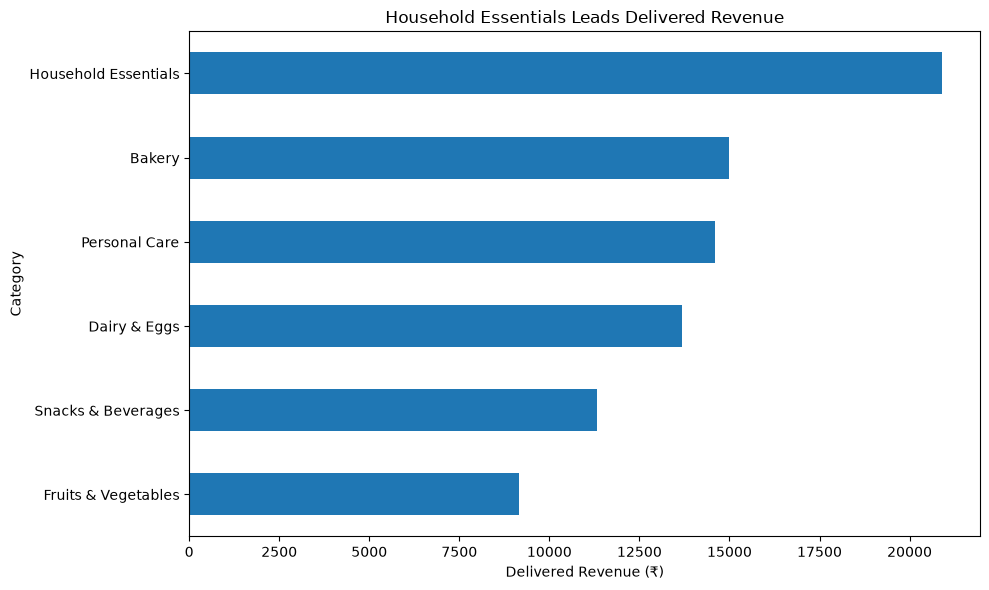

In [18]:
import matplotlib.pyplot as plt

# Chart 1: Delivered revenue by category

category_revenue.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Household Essentials Leads Delivered Revenue")
plt.xlabel("Delivered Revenue (₹)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

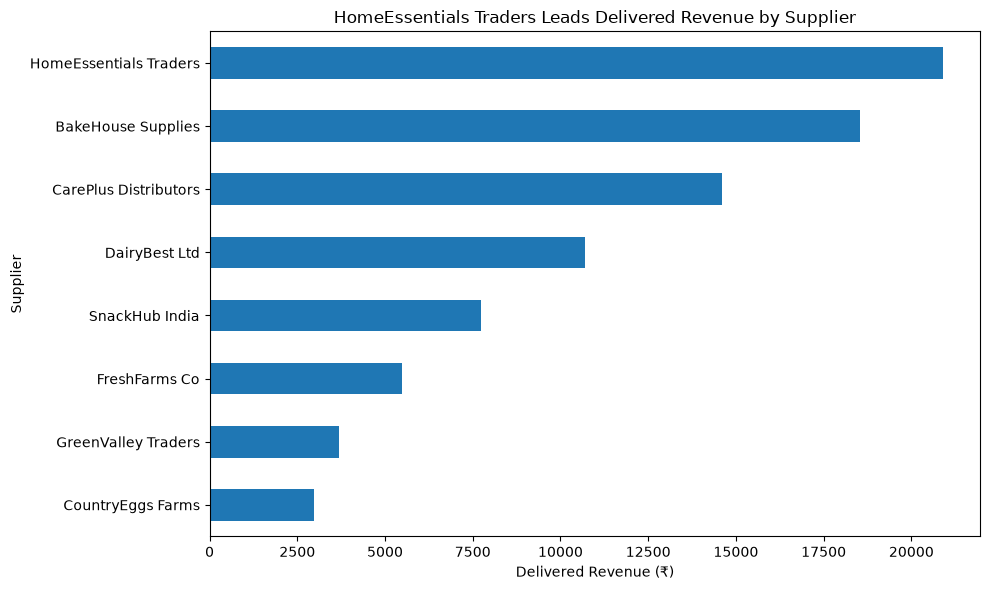

In [19]:
# Chart 2: Delivered revenue by supplier

supplier_revenue.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("HomeEssentials Traders Leads Delivered Revenue by Supplier")
plt.xlabel("Delivered Revenue (₹)")
plt.ylabel("Supplier")
plt.tight_layout()
plt.show()

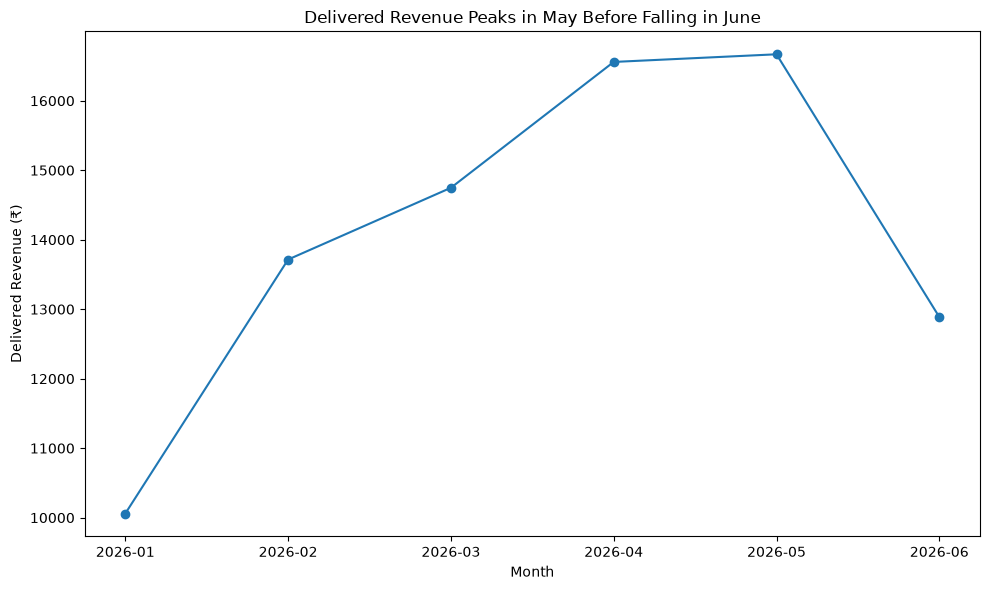

In [21]:
# Chart 3: Monthly delivered revenue trend

monthly_revenue = (
    orders_clean[orders_clean["is_delivered"]]
    .groupby("month")["amount_inr_capped"]
    .sum()
)

monthly_revenue.plot(
    kind="line",
    marker="o",
    figsize=(10, 6)
)

plt.title("Delivered Revenue Peaks in May Before Falling in June")
plt.xlabel("Month")
plt.ylabel("Delivered Revenue (₹)")
plt.tight_layout()
plt.show()

## Key Observations

### 1. What happened?
Household Essentials generated the highest Delivered revenue after outlier capping, at ₹20,910.

### 2. Why does it matter?
HomeEssentials Traders was the top supplier by Delivered revenue at ₹20,910, while monthly Delivered revenue peaked in May before falling in June.

### 3. What should happen next?
The business should investigate the June revenue decline and continue monitoring the performance of Household Essentials and its leading supplier, HomeEssentials Traders.